# Creating Embeddings

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

# Drawing the embeddings
import matplotlib.pyplot as plt

# Deep learning: 
from keras.models import Sequential
from keras.layers import Dense
import tensorflow as tf

#### Loading custom functions

In [6]:
# We load custom functions from a python file
from extra.utility import text_preprocessing, create_unique_word_dict


### Read data

In [8]:
import pdfplumber

pdf_path = 'data/reports_sustainability/Tata Steel UK Limited 2023/Sustainability Report.pdf'

lines = []

with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        if text:
            # split page text into lines
            lines.extend(text.split("\n"))

# now put lines into a DataFrame like before
texts_df = pd.DataFrame({'text': lines})
texts = list(texts_df['text'])
texts[:10]  # preview

['Statutory Reports',
 'BUSINESS RESPONSIBILITY AND SUSTAINABILITY REPORT',
 'Financial Year 2023-2024',
 'Index',
 'SECTION A: GENERAL DISCLOSURES 147',
 'SECTION B: MANAGEMENT AND PROCESS DISCLOSURES 167',
 'SECTION C: PRINCIPLE WISE PERFORMANCE DISCLOSURES 172',
 'Principle 1: B usinesses should conduct and govern themselves with integrity, and in a manner that is 172',
 'ethical, transparent and accountable',
 'Principle 2: Businesses should provide goods and services in a manner that is sustainable and safe 176']

Setting `window=2` to create pairs of 2 words occurring together in the dataset.

In [9]:
# Defining the window for context
window = 2

# Creating a placeholder for the scanning of the word list
word_lists = []
all_text = []

- We go through all the sentences in the dataset. Preprocess the sentences (tokenize and remove stop words)
- We then create pair of words which occur near to each other in a window size equal 2.
  - A pair is created for two words say `a` and `b` like `a,b` and `b,a`

In [10]:
for text in texts:

    # Cleaning the text
    text = text_preprocessing(text)

    # Appending to the all text list
    all_text += text 

    # Creating a context dictionary
    for i, word in enumerate(text):
        for w in range(window):
            # Getting the context that is ahead by *window* words
            if i + 1 + w < len(text): 
                word_lists.append([word] + [text[(i + 1 + w)]])
            # Getting the context that is behind by *window* words    
            if i - w - 1 >= 0:
                word_lists.append([word] + [text[(i - w - 1)]])


In [11]:
word_lists

[['statutory', 'reports'],
 ['reports', 'statutory'],
 ['business', 'responsibility'],
 ['business', 'sustainability'],
 ['responsibility', 'sustainability'],
 ['responsibility', 'business'],
 ['responsibility', 'report'],
 ['sustainability', 'report'],
 ['sustainability', 'responsibility'],
 ['sustainability', 'business'],
 ['report', 'sustainability'],
 ['report', 'responsibility'],
 ['financial', 'year'],
 ['year', 'financial'],
 ['section', 'general'],
 ['section', 'disclosures'],
 ['general', 'disclosures'],
 ['general', 'section'],
 ['disclosures', 'general'],
 ['disclosures', 'section'],
 ['section', 'b'],
 ['section', 'management'],
 ['b', 'management'],
 ['b', 'section'],
 ['b', 'process'],
 ['management', 'process'],
 ['management', 'b'],
 ['management', 'disclosures'],
 ['management', 'section'],
 ['process', 'disclosures'],
 ['process', 'management'],
 ['process', 'b'],
 ['disclosures', 'process'],
 ['disclosures', 'management'],
 ['section', 'c'],
 ['section', 'principle']

Taking out all the unique words from our dataset

In [12]:
unique_word_dict = create_unique_word_dict(all_text)

In [13]:
unique_word_dict

{'+': 0,
 '+free': 1,
 'a+b+c': 2,
 'a+b+c+d+e+f': 3,
 'aa': 4,
 'aan': 5,
 'aashiyana': 6,
 'ab': 7,
 'abac': 8,
 'abide': 9,
 'abilities': 10,
 'ability': 11,
 'able': 12,
 'abled': 13,
 'about': 14,
 'above': 15,
 'absence': 16,
 'abuse': 17,
 'abuses': 18,
 'academia': 19,
 'academic': 20,
 'academy': 21,
 'accelerate': 22,
 'accelerated': 23,
 'accelerating': 24,
 'accept': 25,
 'accepted': 26,
 'access': 27,
 'accessed': 28,
 'accessibility': 29,
 'accessible': 30,
 'accident': 31,
 'accidents': 32,
 'accommodation': 33,
 'accommodations': 34,
 'accordance': 35,
 'according': 36,
 'accordingly': 37,
 'account': 38,
 'accountability': 39,
 'accountable': 40,
 'accountants': 41,
 'accounted': 42,
 'accounting': 43,
 'accounts': 44,
 'accreditation': 45,
 'accurate': 46,
 'ace': 47,
 'aces': 48,
 'achieve': 49,
 'achieved': 50,
 'achievement': 51,
 'achievements': 52,
 'achieving': 53,
 'acknowledges': 54,
 'acquired': 55,
 'acquiredmerged': 56,
 'across': 57,
 'act': 58,
 'acted': 

In [14]:
# Defining the number of features (unique words)
n_words = len(unique_word_dict)

# Getting all the unique words 
words = list(unique_word_dict.keys())

In [15]:
# Creating the X and Y matrices using one hot encoding
X = []
Y = []

for i, word_list in tqdm(enumerate(word_lists)):
    # Getting the indices
    main_word_index = unique_word_dict.get(word_list[0])
    context_word_index = unique_word_dict.get(word_list[1])

    # Creating the placeholders   
    X_row = np.zeros(n_words)
    Y_row = np.zeros(n_words)

    # One hot encoding the main word
    X_row[main_word_index] = 1

    # One hot encoding the Y matrix words 
    Y_row[context_word_index] = 1

    # Appending to the main matrices
    X.append(X_row)
    Y.append(Y_row)

114272it [00:01, 58387.15it/s]


In [16]:
# converting lists to Numpy arrays
X = np.asarray(X)
Y = np.asarray(Y)


In [17]:
# Defining the size of the embedding
embed_size = 2

We build a 1 layer Neural network, with an `input dimension = total number of unique words`, which represents our vocabulary. And the `output dimension = size of vocabulary` to get the embeddings for each word of same dimension.

In [18]:
# Defining the neural network
model = Sequential()

# layers
model.add(Dense(units = embed_size, activation = 'linear', input_dim = X.shape[1]))
model.add(Dense(units = Y.shape[1], activation = 'softmax'))


# Compiling the ANN
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy')
print(model.summary())

/Users/aposkoub/ds_ai/sus_project/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │         9,810 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4904)           │        14,712 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,522 (95.79 KB)

 Trainable params: 24,522 (95.79 KB)

 Non-trainable params: 0 (0.00 B)

None


In [20]:

# Optimizing the network weights
model.fit(
    x=X, 
    y=Y, 
    batch_size=256,
    epochs=100,
    )


Epoch 1/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.9589
Epoch 2/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.9472
Epoch 3/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.9402
Epoch 4/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.9351
Epoch 5/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.9306
Epoch 6/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.9267
Epoch 7/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.9227
Epoch 8/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.9185
Epoch 9/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.9137
Epoch 10/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.9080
Epoch 11/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.9013
Epoch 12/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.8947
Epoch 13/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.8890
Epoch 14/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.8840
Epoch 15/100
447/447 ━━━━━━━━━━━━━━━━━━━━ 3

After training the network, we extract the trained weights from the first layer of the neural network, which will be the embeddings for our vocabulary

In [21]:
# The input layer 
weights = model.get_weights()[0]

In [22]:
# Creating a dictionary to store the embeddings in. The key is a unique word and 
# the value is the numeric vector
embedding_dict = {}
for word in words: 
    embedding_dict.update({
        word: weights[unique_word_dict.get(word)]
        })

#### 2D visualization

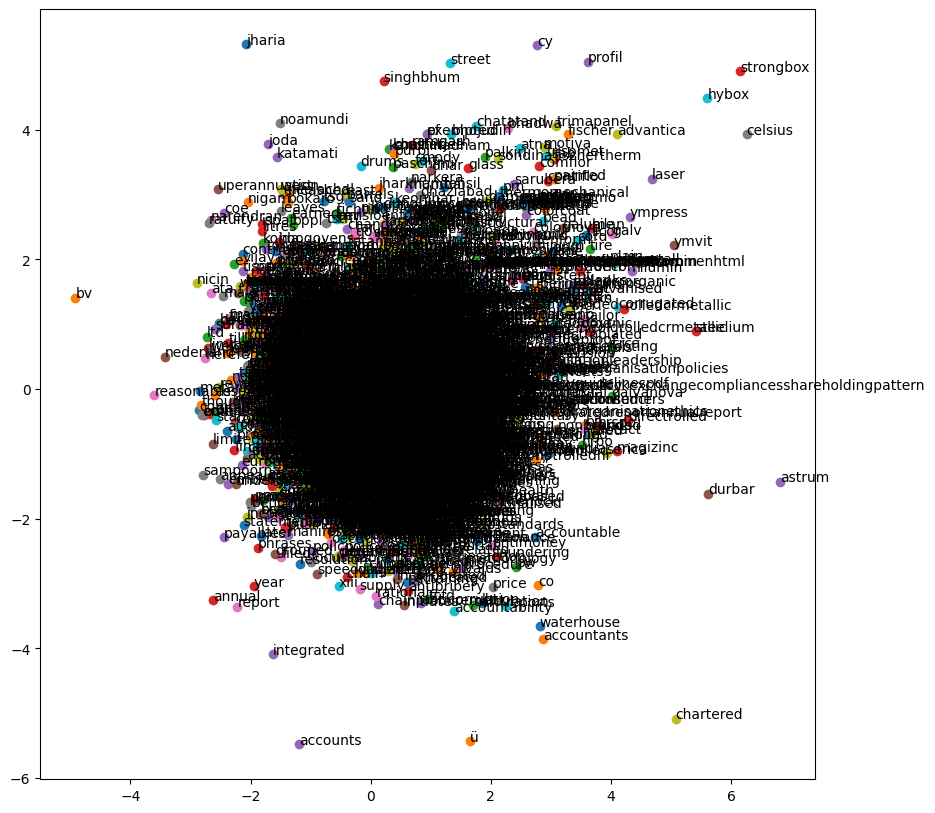

In [23]:
# Plotting the embeddings
plt.figure(figsize=(10, 10))
for word in list(unique_word_dict.keys()):
    coord = embedding_dict.get(word)
    plt.scatter(coord[0], coord[1])
    plt.annotate(word, (coord[0], coord[1]))       


#### Visualization in 3D

We can also visualize the embeddings in 3-dimensions. For this change the `embed_size` to `3` by scrolling 5-6 cells above and running the cells again. Also Uncomment the code cell below to visualize embeddings in 3D

In [20]:
# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')
# # Plotting the embeddings
# plt.figure(figsize=(10, 10))
# for word in list(unique_word_dict.keys()):
#     coord = embedding_dict.get(word)
#     ax.scatter(coord[0], coord[1],coord[2])
#     ax.text(coord[0], coord[1], coord[2],word)    

In [24]:
# Saving the embedding vector to a txt file
try:
    os.mkdir(f'{os.getcwd()}//embeddings_output')        
except Exception as e:
    print(f'Cannot create output folder: {e}')

In [25]:
with open(f'{os.getcwd()}//embeddings_output//embedding.txt', 'w') as f:
    for key, value in embedding_dict.items():
        try:
            f.write(f'{key}: {value}\n')   
        except Exception as e:
            print(f'Cannot write word {key} to dict: {e}') 

 - These embeddings are later used on a large scale as an Embedding layer in different neural networks trained for NLP tasks <br> 
 - As we increase the embedding size, i.e., the size of the vector for each word in the vocabulary, the more accurate we get the results. <br> 
 - Try changing the embedding size to 3 (but the plot will have to be 3D then). Try plotting it on the same 2D scatter plot and notice if there are any differences.